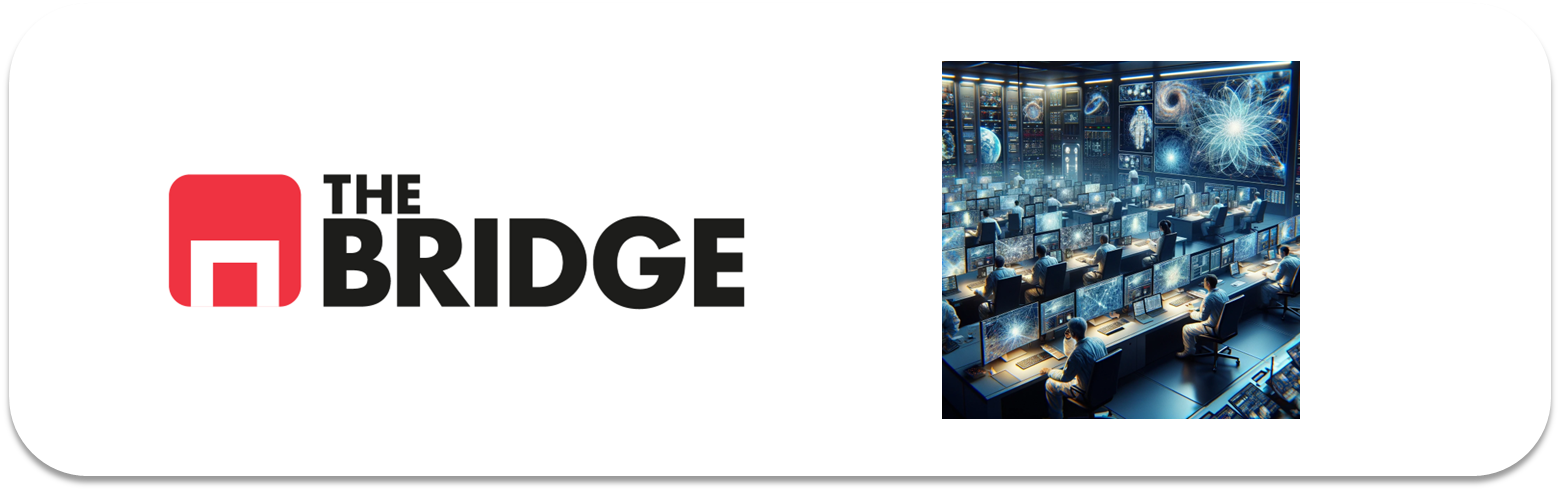

## PRACTICA OBLIGATORIA: **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en un ejercicio de construcción de una red convolucional con Keras para la clasificación de imagenes de simpáticos perretes y gatetes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bootcampviztools import *
import cv2
from PIL import Image
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import warnings
warnings.filterwarnings('ignore')
print('Librerías importadas correctamente')
print(f'TensorFlow version: {tf.__version__}')

Librerías importadas correctamente
TensorFlow version: 2.21.0


### Problema de Negocio y dataset

Una conocida empresa de información inmobiliaria utiliza un CAPTCHA visual de perros y gatos para detectar webscrappings intensivos y ataques de denegación de servicio. Últimamente, ha detectado que su sistema está empezando a flojear, es decir que hay muchos sistemas de detección automática de imágenes que son capaces de detectar que es un perro y un gato y salterse el CAPTCHA antirobots. Por eso nos ha pedido que entrenemos un modelo potente de clasificación que emule a estos sistemas con el objetivo de emplear como fotografías para el CAPTCHA aquellas que no sepa detectar este sistema emulador de chicos malos.  

Pues manos a la obra, tenemos que seleccionar en un conjunto de 1000 imágenes aquellas que peor se le daría clasificar a un potencial sistema anti-CAPTCHA.  

Para ello vamos a emplear un conjunto de train de 4000 imágenes de perretes y gatetes que se encuentran distribuidas en "data" en cuatro directorios "github_train_0",  "github_train_1", "githun_train_2" y "github_train_3". Los datos de las imagenes que tenemos que clasificar y luego seleccionar como las más "difíciles" están en "data" en el directorio "github_test".


### Se pide

1. Crear los datasets X,y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adpatar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad. NOTA: Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.

2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas :-). Muestra su historial de entrenamiento.

4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.

5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perror más alta.


### Extra (para hacer en clase)

Repite los pasos 3 a 5 utilizando el generador de imágenes sintéticas o Image Augmentation de Keras. 



### Exploración de los datos

Número de imágenes por directorio:
Train 0: 1000 imágenes
Train 1: 1000 imágenes
Train 2: 1000 imágenes
Train 3: 1000 imágenes
Test: 1000 imágenes

Ejemplos de nombres de archivos:
Train 0: ['cat.1000.jpg', 'cat.10010.jpg', 'cat.10012.jpg', 'cat.10013.jpg', 'cat.10017.jpg']
Train 2: ['dog.10001.jpg', 'dog.10004.jpg', 'dog.10008.jpg', 'dog.10009.jpg', 'dog.10013.jpg']


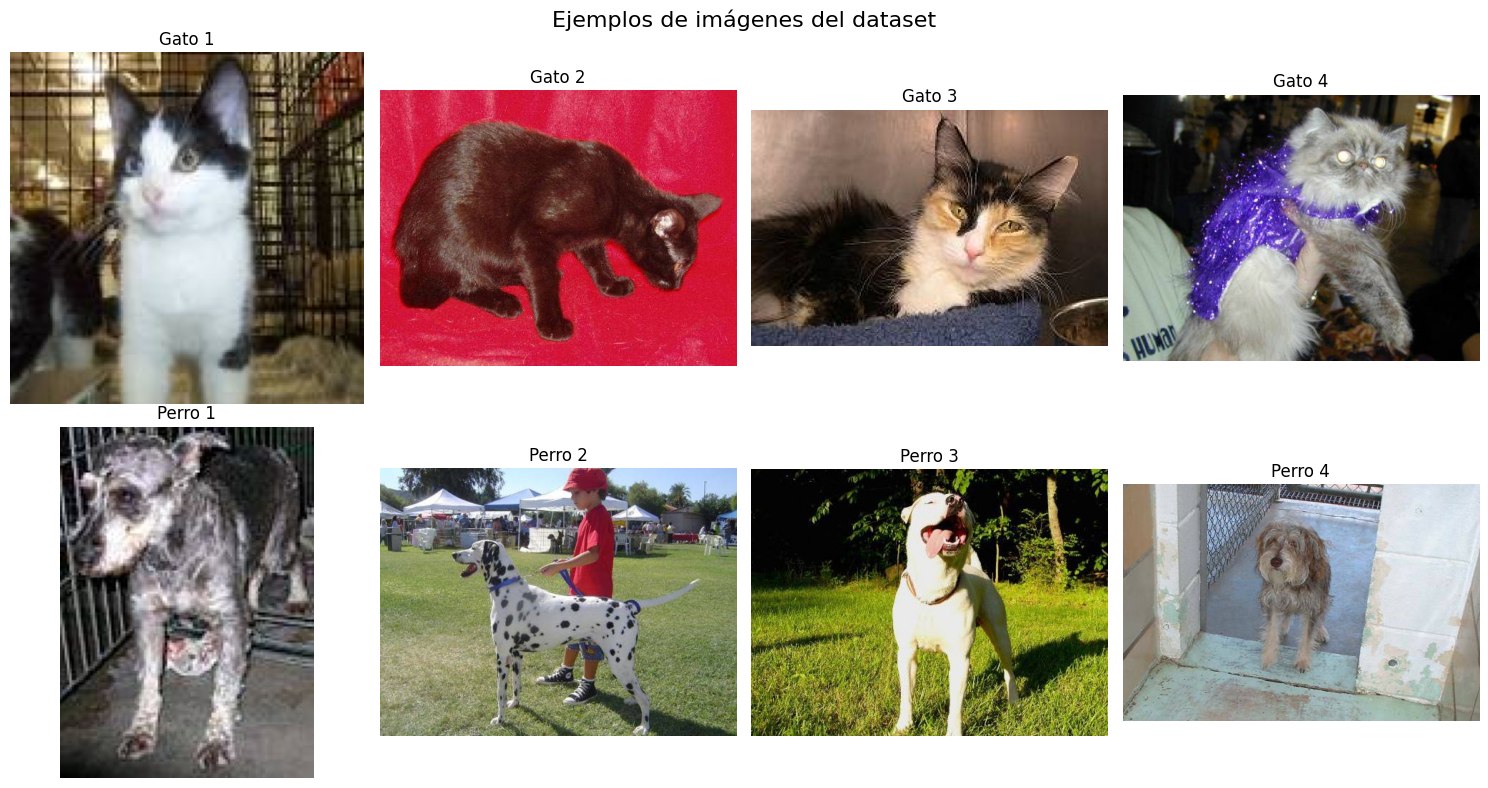

In [11]:
train_dir_0 = 'data/github_train_0'
train_dir_1 = 'data/github_train_1'
train_dir_2 = 'data/github_train_2'
train_dir_3 = 'data/github_train_3'
test_dir = 'data/github_test'

print('Número de imágenes por directorio:')
print(f'Train 0: {len(os.listdir(train_dir_0))} imágenes')
print(f'Train 1: {len(os.listdir(train_dir_1))} imágenes')
print(f'Train 2: {len(os.listdir(train_dir_2))} imágenes')
print(f'Train 3: {len(os.listdir(train_dir_3))} imágenes')
print(f'Test: {len(os.listdir(test_dir))} imágenes')

print('\nEjemplos de nombres de archivos:')
print('Train 0:', os.listdir(train_dir_0)[:5])
print('Train 2:', os.listdir(train_dir_2)[:5])

fig, axes = plt.subplots(2, 4, figsize=(15, 8))
fig.suptitle('Ejemplos de imágenes del dataset', fontsize=16)

# Gatos del train_0
for i in range(4):
    img_path = os.path.join(train_dir_0, os.listdir(train_dir_0)[i])
    img = Image.open(img_path)
    axes[0, i].imshow(img)
    axes[0, i].set_title(f'Gato {i+1}')
    axes[0, i].axis('off')

# Perros del train_2
for i in range(4):
    img_path = os.path.join(train_dir_2, os.listdir(train_dir_2)[i])
    img = Image.open(img_path)
    axes[1, i].imshow(img)
    axes[1, i].set_title(f'Perro {i+1}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

Exploración inicial del dataset:

1. **Estructura de directorios**: Tenemos 4 directorios de entrenamiento y 1 de test
2. **Cantidad de imágenes**: Cada directorio contiene 1000 imágenes
3. **Nomenclatura**: Los archivos siguen el patrón `cat.XXXXX.jpg` o `dog.XXXXX.jpg`
4. **Visualización**: He mostrado ejemplos de gatos y perros para ver la variabilidad en las imágenes


Las imágenes tienen diferentes tamaños y orientaciones. Además hay variabilidad en fondos, iluminación y poses.Necesitaremos preprocesar las imágenes para que tengan el mismo tamaño.

### Preparación de los datos

In [12]:
import shutil


os.makedirs('data/train/cat', exist_ok=True)
os.makedirs('data/train/dog', exist_ok=True)
os.makedirs('data/validation/cat', exist_ok=True)
os.makedirs('data/validation/dog', exist_ok=True)


cat_images = []
for dir_name in ['data/github_train_0', 'data/github_train_1']:
    for img_name in os.listdir(dir_name):
        if 'cat' in img_name:
            cat_images.append(os.path.join(dir_name, img_name))


dog_images = []
for dir_name in ['data/github_train_2', 'data/github_train_3']:
    for img_name in os.listdir(dir_name):
        if 'dog' in img_name:
            dog_images.append(os.path.join(dir_name, img_name))

print(f'Total imágenes de gatos: {len(cat_images)}')
print(f'Total imágenes de perros: {len(dog_images)}')


from sklearn.model_selection import train_test_split

cat_train, cat_val = train_test_split(cat_images, test_size=0.2, random_state=42)
dog_train, dog_val = train_test_split(dog_images, test_size=0.2, random_state=42)

Total imágenes de gatos: 2000
Total imágenes de perros: 2000


He reorganizado los datos para facilitar el entrenamiento:

1. **Estructura de directorios**: Creé carpetas `train/cat`, `train/dog`, `validation/cat`, `validation/dog`
2. **Agrupación**: Junté las imágenes de gatos (train_0 y train_1) y perros (train_2 y train_3)
3. **División**: Usé un split 80-20 para train/validation

Esta estructura es la que espera `ImageDataGenerator` de Keras.

In [13]:
IMG_SIZE = 150  #
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,           
    rotation_range=40,        
    width_shift_range=0.2,    
    height_shift_range=0.2,   
    shear_range=0.2,          
    zoom_range=0.2,           
    horizontal_flip=True,     
    fill_mode='nearest'       
)


val_datagen = ImageDataGenerator(rescale=1./255)


train_generator = train_datagen.flow_from_directory(
    'data/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'  
)

validation_generator = val_datagen.flow_from_directory(
    'data/validation',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

print(f'Clases encontradas: {train_generator.class_indices}')

Found 0 images belonging to 2 classes.
Found 0 images belonging to 2 classes.
Clases encontradas: {'cat': 0, 'dog': 1}


Aumentamos artificialmente el tamaño del dataset para ayudar a prevenir overfitting y hacer el modelo más robusto a variaciones.

**Transformaciones aplicadas**:
- **Rotación**: Hasta 40 grados
- **Desplazamientos**: 20% en horizontal y vertical
- **Zoom**: Hasta 20%
- **Flip horizontal**: Espejado de la imagen


### Construcción de la red

In [14]:

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2, 2),
    
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    Flatten(),
    
    Dropout(0.5),  
    Dense(512, activation='relu'),
    
    Dense(1, activation='sigmoid')  
])


model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento

In [15]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

EPOCHS = 20

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print('\nEntrenamiento completado!')

ValueError: The PyDataset has length 0

**Callbacks utilizados**:

1. **EarlyStopping**:
   - Monitorea `val_loss`
   - Patience=5: Espera 5 épocas sin mejora antes de parar
   - Restaura los mejores pesos encontrados
   - Previene overfitting y ahorra tiempo

2. **ModelCheckpoint**:
   - Guarda el mejor modelo según `val_accuracy`
   - Solo guarda cuando hay mejora
   - Permite recuperar el mejor modelo después

**Parámetros**:
- **EPOCHS=20**: Máximo de épocas (puede parar antes con early stopping)
- El modelo aprende iterativamente ajustando pesos para minimizar la pérdida

 Me da error y no caigo en por qué